In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 10

Durante un brote de una enfermedad en la ciudad de Macondo se puede dividir a la población entre los grupos *susceptibles* de contraer la enfermedad $(S)$, *infectados* $(I)$ y *recuperados* $(R)$. La relación entre el número de personas en cada grupo está definida por el siguiente sistema de ODEs:

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

con $\beta$ y $\gamma$ las tasas de infección y recuperación respectivamente.

### (a)
Considerar que la ciudad tiene una población de $N = 10000$ habitantes e inicialmente todas las personas son susceptibles. Supondremos una tasa de transmisión $\beta = 0{,}2$ y un tiempo medio de recuperación de $10$ días. Si inicialmente hay una única persona enferma, discutir de qué forma deberían evolucionar las poblaciones de cada grupo.

### (b)
Simular y graficar la solución a partir de una función $f(u,p,t)$ que compute la derivada $du$ aplicando las ecuaciones.

### (c)
Asumiendo que no se producen fallecimientos, verificar que la población de la ciudad se mantiene constante a lo largo de la simulación.

### (d)
Determinar el tiempo a partir del cual, sin acciones externas, la cantidad de infecciones comienza a descender.

In [11]:
# Ejercicio 10

def sistema(t, estado, beta, gamma, N):
    s, i, r = estado
    dSdt = -beta * (s*i)/N
    dIdt = beta * (s*i)/N - gamma * i
    dRdt = gamma * i

    return np.array([dSdt, dIdt, dRdt])

def euler(s0, i0, r0, beta, gamma, N, t0, tf, h):
    t_valores = [t0]
    s_valores = [s0]
    i_valores = [i0]
    r_valores = [r0]

    t, s, i, r = t0, s0, i0, r0

    while t < tf:
        estado = np.array([s, i, r])
        pendiente = sistema(t, estado, beta, gamma, N)

        estado = estado + h * pendiente
        s, i, r = estado
        
        t = t + h

        t_valores.append(t)
        s_valores.append(s)
        i_valores.append(i)
        r_valores.append(r)

    return np.array(t_valores), np.array(s_valores), np.array(i_valores), np.array(r_valores)

tiempos, susceptibles, infectados, recuperados = euler(9999, 1, 0, 0.2, 0.1, 10000, 0, 200, 0.01)

print(f'Al cabo de {tiempos[-1]:.0f} días quedan {susceptibles[-1]:.0f} personas susceptibles, {infectados[-1]:.0f} personas infectadas t {recuperados[-1]:.0f} personas recuperadas')


Al cabo de 200 días quedan 2035 personas susceptibles, 6 personas infectadas t 7958 personas recuperadas


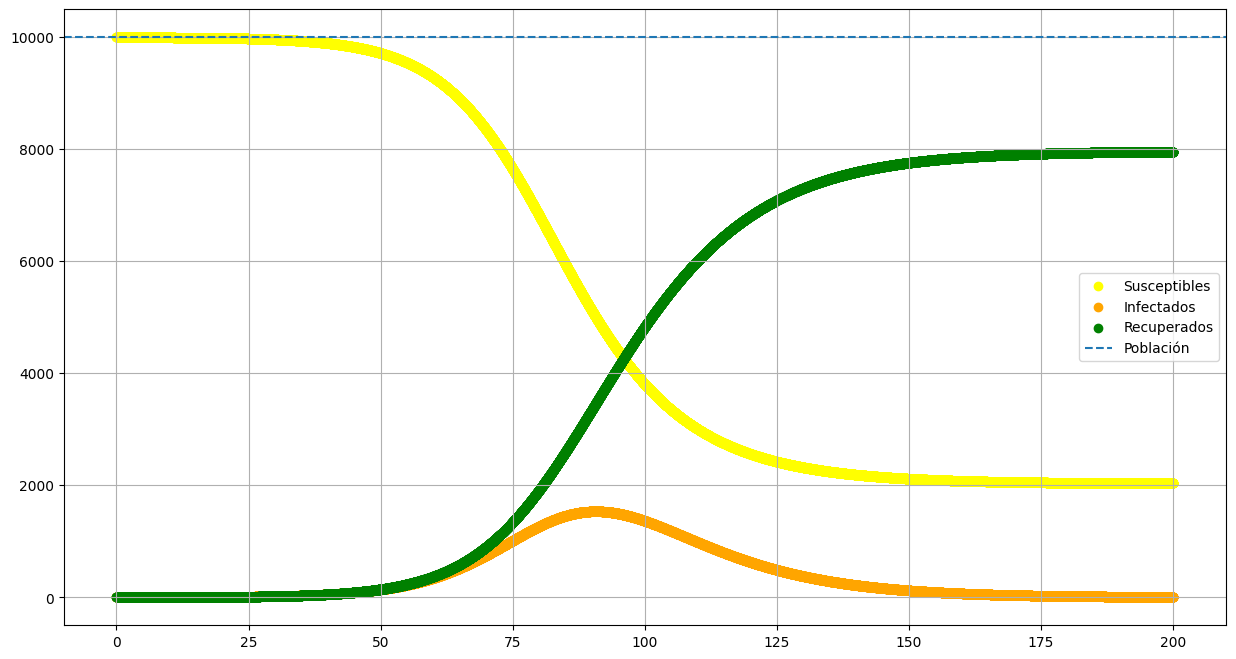

In [12]:
plt.figure(figsize=(15,8))
plt.scatter(tiempos, susceptibles, label='Susceptibles', color='yellow')
plt.scatter(tiempos, infectados, label='Infectados', color='orange')
plt.scatter(tiempos, recuperados, label='Recuperados', color='green')
plt.axhline(10000, linestyle='--', label='Población')

plt.grid(True)
plt.legend()
plt.show()